# in this notebook, we would like to fit the optimal G value based on the BOLD simulations

In [1]:
# Generic stuff
import time
import os, sys,glob, numpy as np, pandas as pd
from scipy.io import loadmat
from itertools import product
from scipy.interpolate import interp1d
from copy import deepcopy

import torch
from sbi import utils as utils
from sbi.inference.base import infer
from sbi import analysis as analysis
import numpy as np
    
# Viz stuff
%matplotlib inline
from matplotlib import pyplot as plt

from examples.tvb_nest.notebooks.cerebellum.scripts.scripts import *
# Get configuration
config, plotter = configure()

from tvb_multiscale.core.plot.plotter import Plotter
plotter = Plotter(config.figures)

plotter.config.DEFAULT_SIZE = (12, 10)  # FIGSIZE

from examples.tvb_nest.notebooks.cerebellum import utils

#umcomment upon first usage
import sys
!{sys.executable} -m pip install xlrd
import xlrd
from tvb_multiscale.core.utils.file_utils import load_pickled_dict

2023-02-23 08:51:14,878 - INFO - tvb_multiscale.tvb_nest.config - Loading a NEST instance...
2023-02-23 08:51:14,878 - INFO - tvb_multiscale.tvb_nest.config - Loading a NEST instance...
2023-02-23 08:51:14,897 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/env/neurosci/nest_build
2023-02-23 08:51:14,897 - INFO - tvb_multiscale.tvb_nest.config - NEST_INSTALL_DIR: /home/docker/env/neurosci/nest_build
2023-02-23 08:51:14,900 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/env/neurosci/nest_build/share/nest
2023-02-23 08:51:14,900 - INFO - tvb_multiscale.tvb_nest.config - NEST_DATA_DIR: /home/docker/env/neurosci/nest_build/share/nest
2023-02-23 08:51:14,903 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/env/neurosci/nest_build/share/doc/nest
2023-02-23 08:51:14,903 - INFO - tvb_multiscale.tvb_nest.config - NEST_DOC_DIR: /home/docker/env/neurosci/nest_build/share/doc/nest
2023-02-23 08:51:14,905 - INFO - tvb_multiscale.tv

Outputs' path: /home/docker/packages/tvb-multiscale/examples/tvb_nest/notebooks/cerebellum/ctwc-model-master/notebooks/outputs/cwc
Config (
  title .............................. 'Config gid: 563d4d48-351e-412c-b823-d5b6d47edff1'
  Type ............................... 'Config'
  gid ................................ UUID('563d4d48-351e-412c-b823-d5b6d47edff1')
  config.gid ......................... UUID('563d4d48-351e-412c-b823-d5b6d47edff1')
  config.title ....................... 'Config gid: 563d4d48-351e-412c-b823-d5b6d47edff1'
  config.log ......................... <Logger tvb_multiscale.tvb_nest.config (DEBUG)>
  config.out ......................... OutputConfig gid: d92e7087-e656-421e-82ce-fbb53f559960
  config.figures ..................... FiguresConfig
  config.DEFAULT_SUBJECT[connectivity]  Connectivity gid: d1d2cf83-2064-4e37-a9b4-7854753f2b2a
  config.DEFAULT_SUBJECT[cortex] ..... Cortex gid: af004511-d713-4158-a034-b7f59ede2adb
  config.DEFAULT_SUBJECT_PATH ........ '/home/d

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 1.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip available: 22.1.2 -> 23.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


<Figure size 432x288 with 0 Axes>

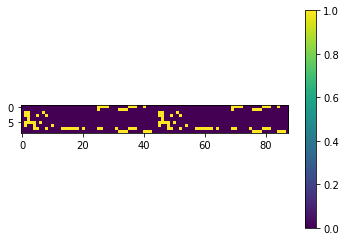

In [2]:
#################################################
#load the resting-state networks
#################################################
jj=0.1
path = glob.glob('/home/docker/packages/tvb-multiscale/examples/data/cerebellum/cwcBOLD/G' + str(jj) + "/*" + '/res')
bold_G01 = path[0] + "/bold_ts.pkl"
bold = load_pickled_dict(bold_G01)

sheet_data = []   
wb = xlrd.open_workbook('/home/docker/packages/tvb-multiscale/examples/data/cerebellum/oh_table1.xls')
p = wb.sheet_names()
sh = wb.sheet_by_name(p[1])
for rownum in range(sh.nrows):
    sheet_data.append((sh.row_values(rownum)))

#now I would like to find the region label and then look whether it corresponds to some rs net
#from the region labels above in bold region labels we need which indices are part of DMN for example

#for each of our 214 region labels, I will need a vector of regional involvement for each of the 9 rs networks
#so look for these region labels in the table and extract the numbers for the 9 rs networks
rows = 214
cols = 9
rs_net = [[0 for _ in range(rows)] for _ in range(cols)] #first dimension is 9, second dimension is 214

for p in range (0,9): #go over all RS nets
    found_list = []
    rows_to_be_saved = []
    regions_missing = []
    cc=0
    specthal=[]
    subc=[]

    for j in bold['region_labels']: #go over the region labels
        j=j.split(" ",1)[1] #let us get rid of the left or right
        a=len(found_list)
        for i in sheet_data:
            if i[3] == j: 
                found_list.append(i[17+p])
            else:
                rows_to_be_saved.append(i)

        b=len(found_list)
        if a == b: #then we did not find that region label in the excel sheet
            k = 1
            while sheet_data[k][4]!=j: #look whether that region label is in the major regions
                k += 1
                if k>324: #then we did not find this region label in the major regions either
                    k=324
                    break
            if sheet_data[k][4] == j: 
                    b=len(found_list)
                    subc.append(b)
                    found_list.append(sheet_data[k][17+p]) #here we match multiple times but we only want the first match

        b=len(found_list) 
        if a == b: #then we did not find that region label in the major regions and are left with specific thalamus 
            j=j.split(" ",1)[1][:8] #get rid of specific and leave only thalamus
            k = 1
            while sheet_data[k][4]!=j: #look for the thalamus in the major regions
                k += 1
                if k>324:
                    k=324
                    break
            if sheet_data[k][4] == j: 
                    b=len(found_list)
                    #and write their index j in a vector
                    specthal.append(b)
                    found_list.append(0) #write a 0 if we have a specific thalamus region here 
                    #because we will not consider those as involved in RS nets

        b=len(found_list) 
        if a == b: #then we did not find that region label in the excel sheet       
            regions_missing.append(j)
            found_list.append('X')
            print(a,b)


        b=len(found_list)
        cc+=1
        if b != cc:
            print(b,cc)

    rs_net[p][:]=found_list
dd=list(range(43,106))
dd=dd + list(range(150,213))
#dd= specthal + subc
#dd=np.concatenate(range(43,106),range(150,213))
#rs_net=np.delete(rs_net, specthal,1)
rs_net=np.delete(rs_net, dd,1)
plt.figure()
plt.imshow(rs_net)#, extent=[0, 1, 0, 1])
plt.colorbar()
plt.show()

G = 0.1


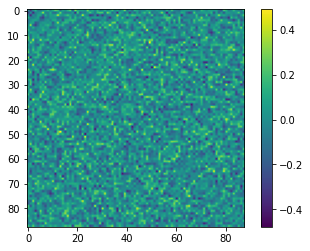

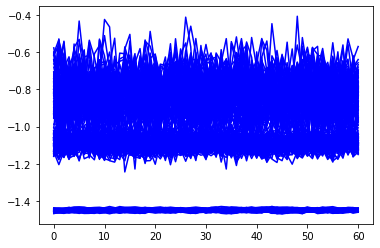

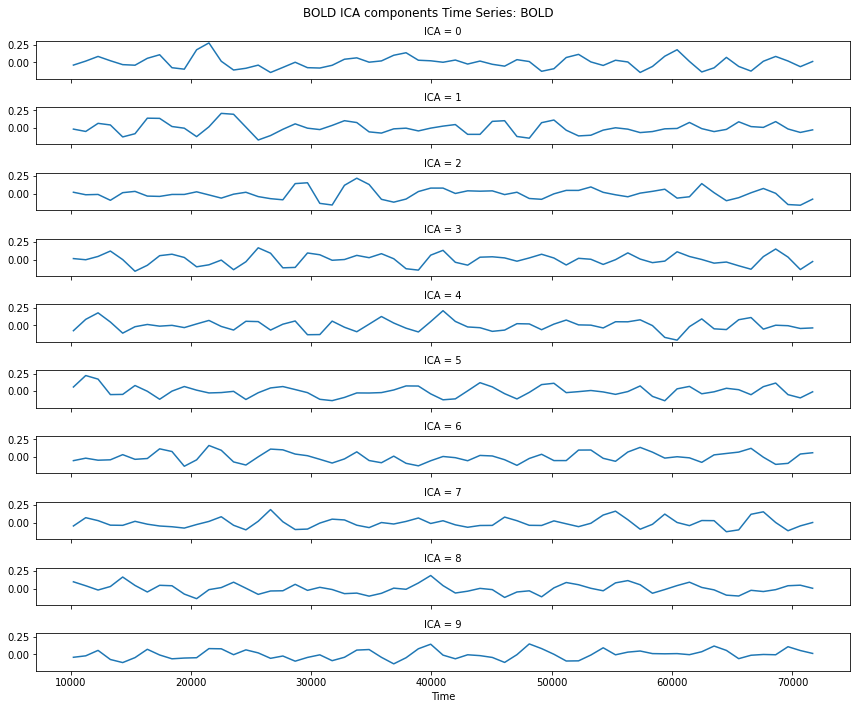

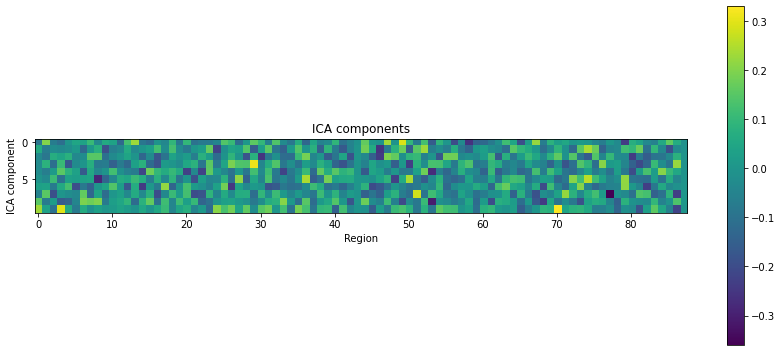

maximum correlation =  0.3431020797919995


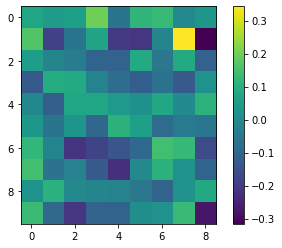

Indices of paired PCs with all 9 RS networks: [3, 7, 'X', 'X', 'X', 'X', 'X', 'X', 'X']
G = 1


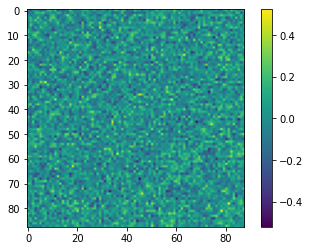

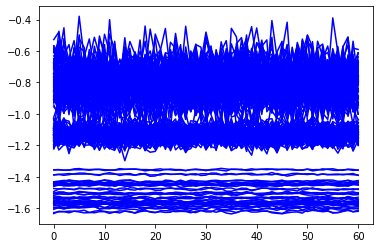

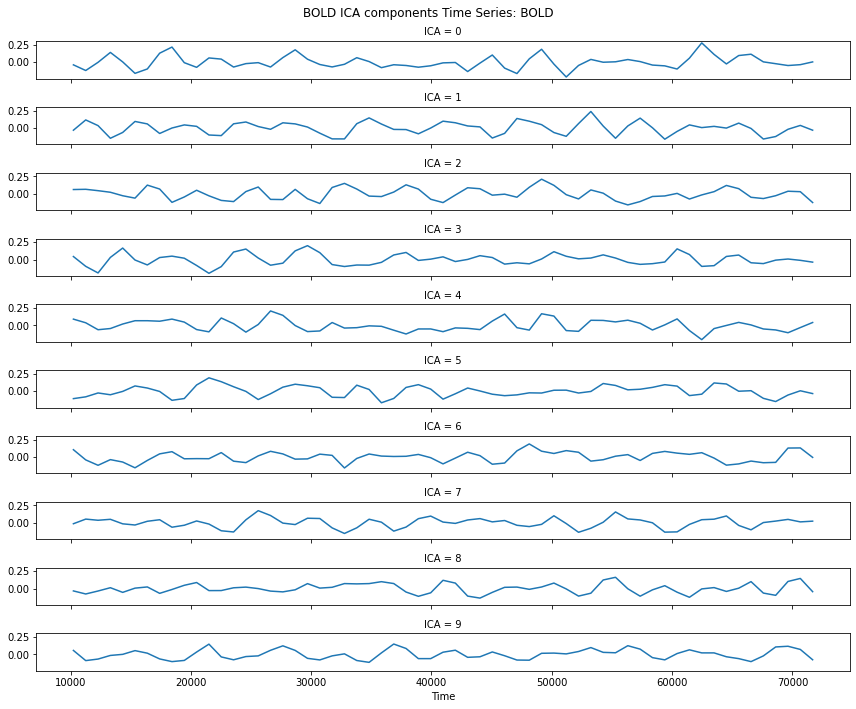

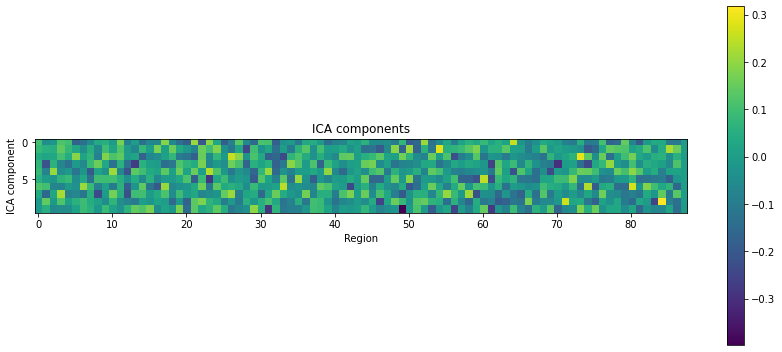

maximum correlation =  0.23144068631618908


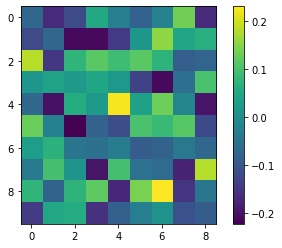

Indices of paired PCs with all 9 RS networks: ['X', 'X', 0, 'X', 4, 'X', 'X', 8, 6]
G = 2


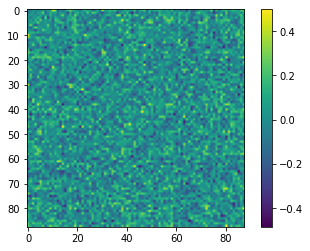

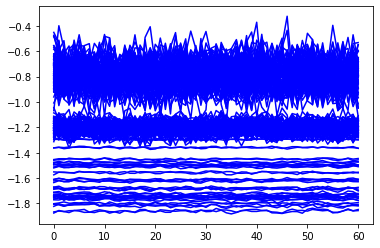

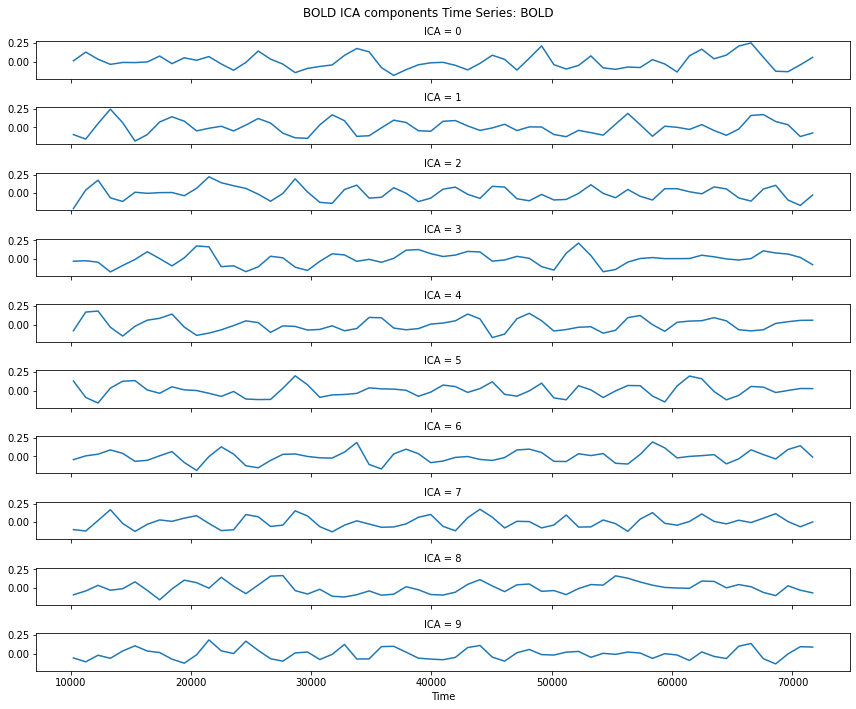

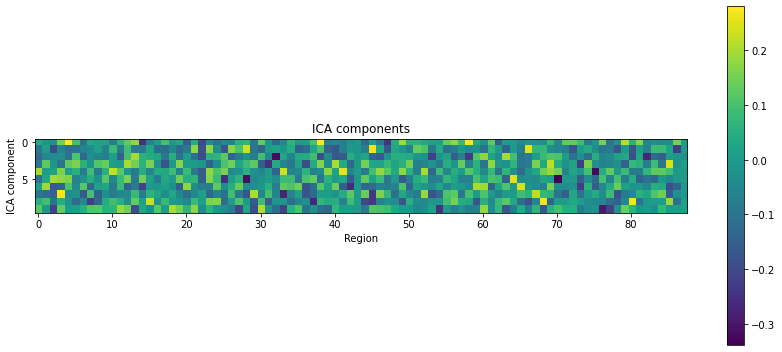

maximum correlation =  0.3621267620266214


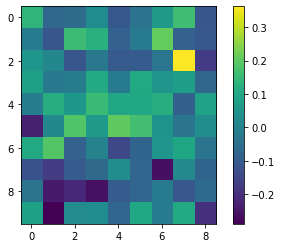

Indices of paired PCs with all 9 RS networks: ['X', 6, 7, 'X', 'X', 4, 1, 'X', 'X']
G = 3


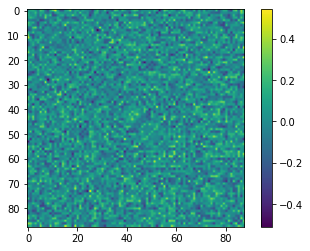

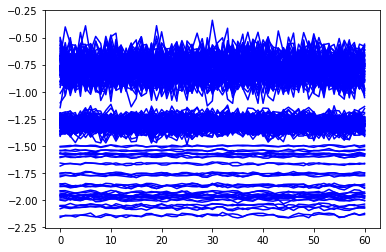

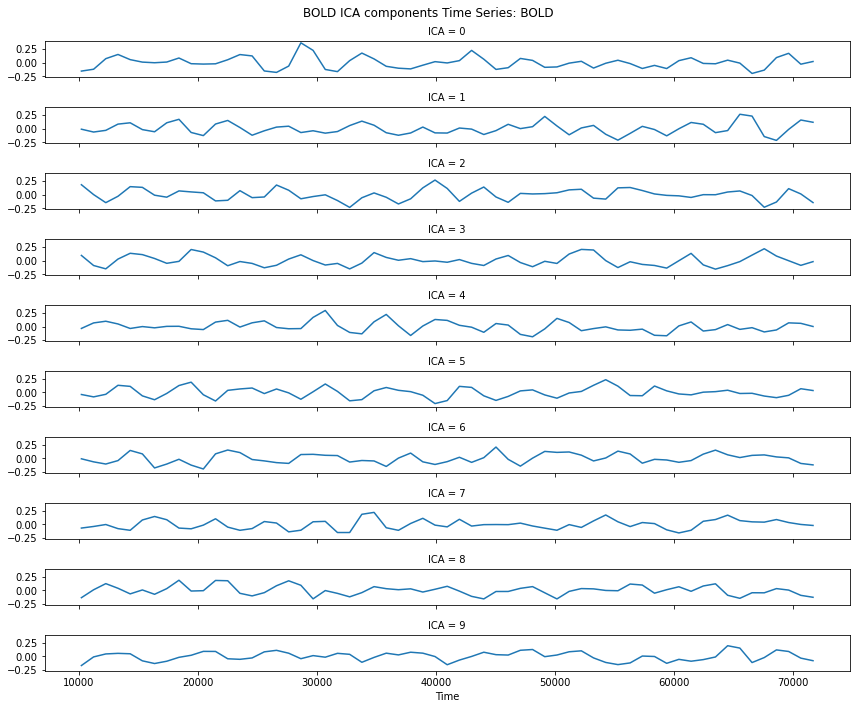

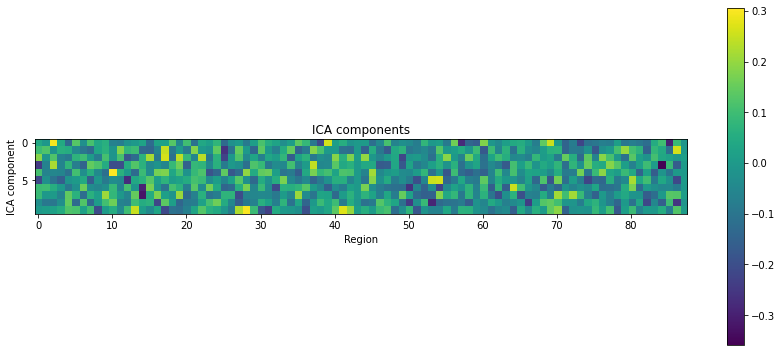

maximum correlation =  0.19014999399599591


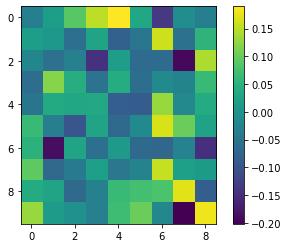

Indices of paired PCs with all 9 RS networks: [4, 'X', 'X', 'X', 'X', 'X', 'X', 'X', 7]
G = 4


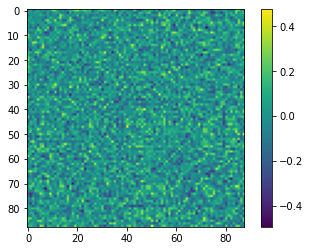

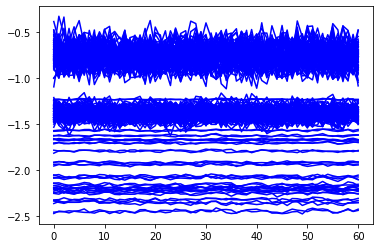

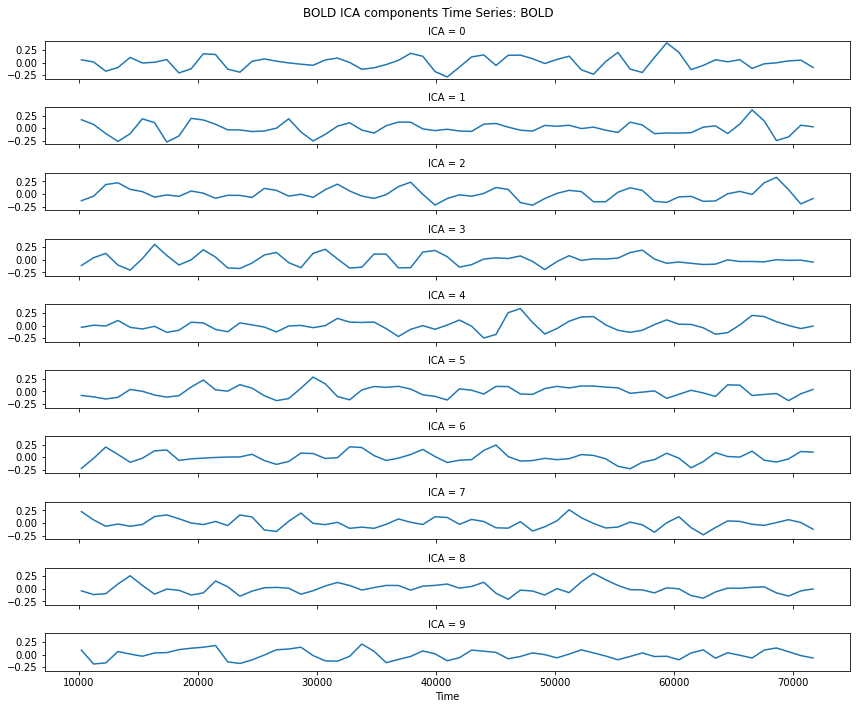

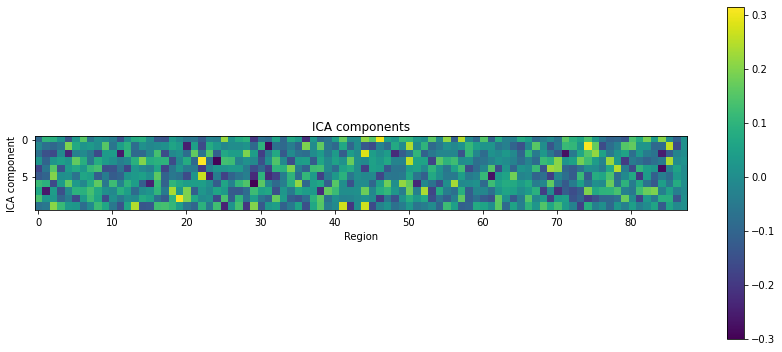

maximum correlation =  0.3681749559768749


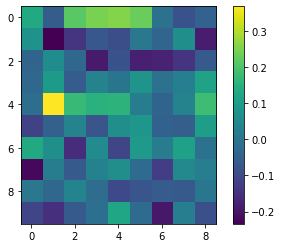

Indices of paired PCs with all 9 RS networks: [4, 'X', 'X', 'X', 1, 'X', 'X', 'X', 'X']
G = 5


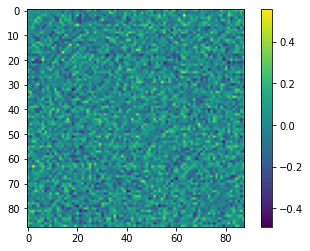

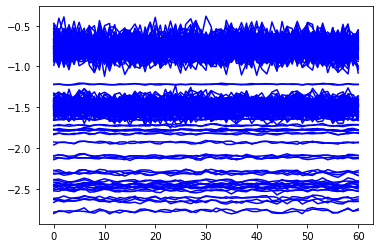

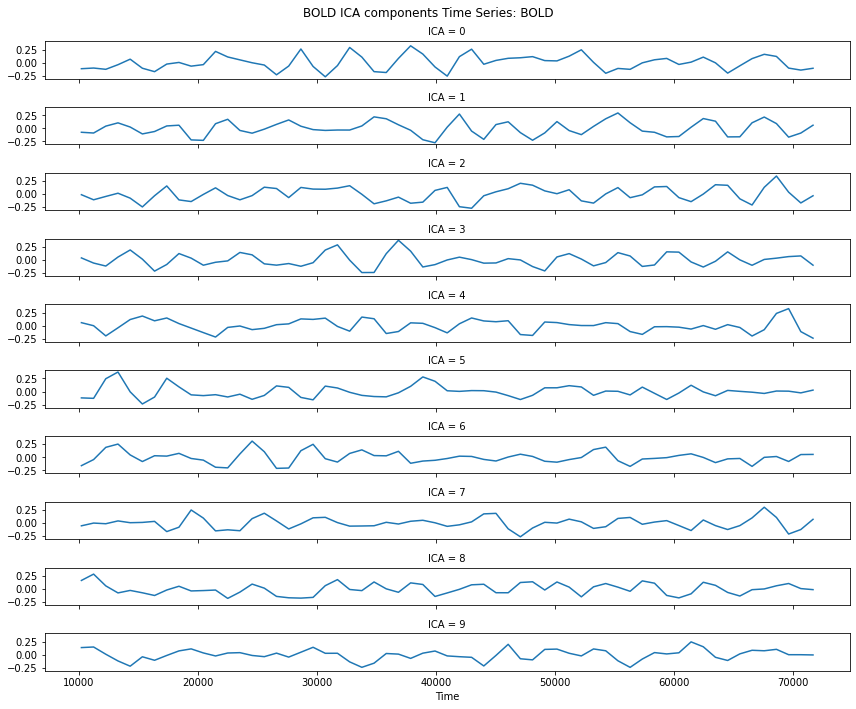

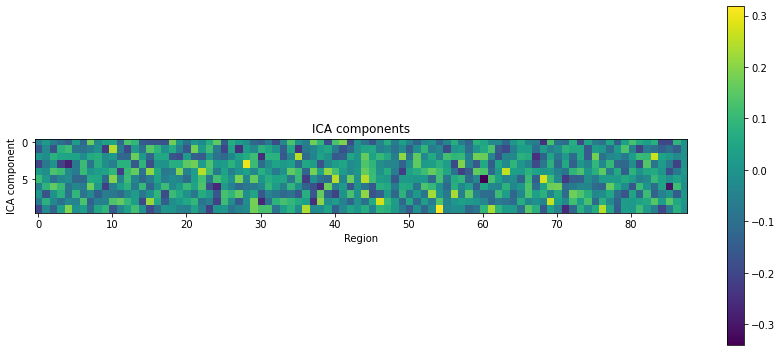

maximum correlation =  0.20926097282332212


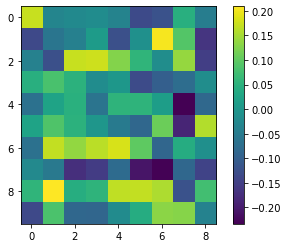

Indices of paired PCs with all 9 RS networks: [0, 6, 3, 'X', 'X', 'X', 4, 'X', 1]
G = 6


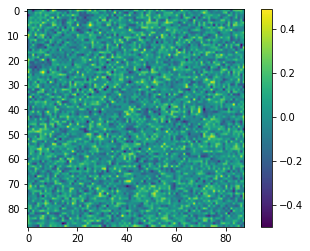

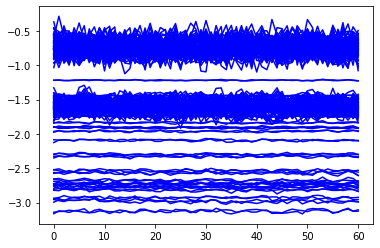

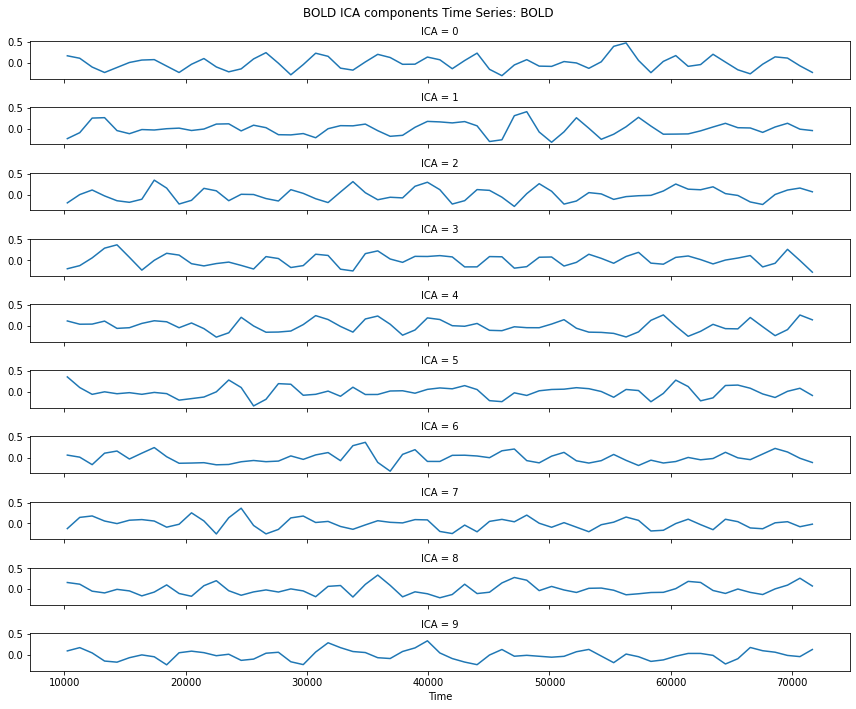

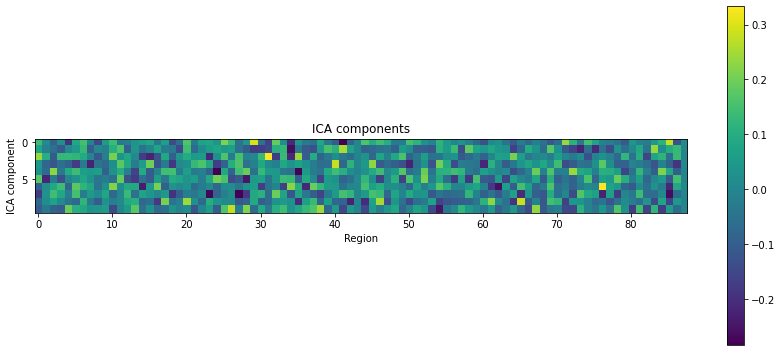

maximum correlation =  0.3182368738370201


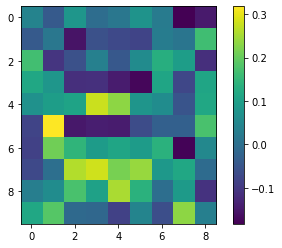

Indices of paired PCs with all 9 RS networks: ['X', 'X', 'X', 'X', 3, 1, 1, 3, 4]
G = 7


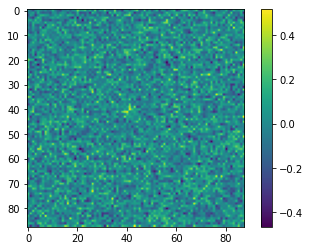

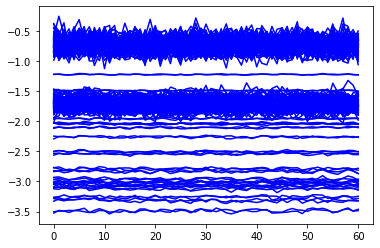

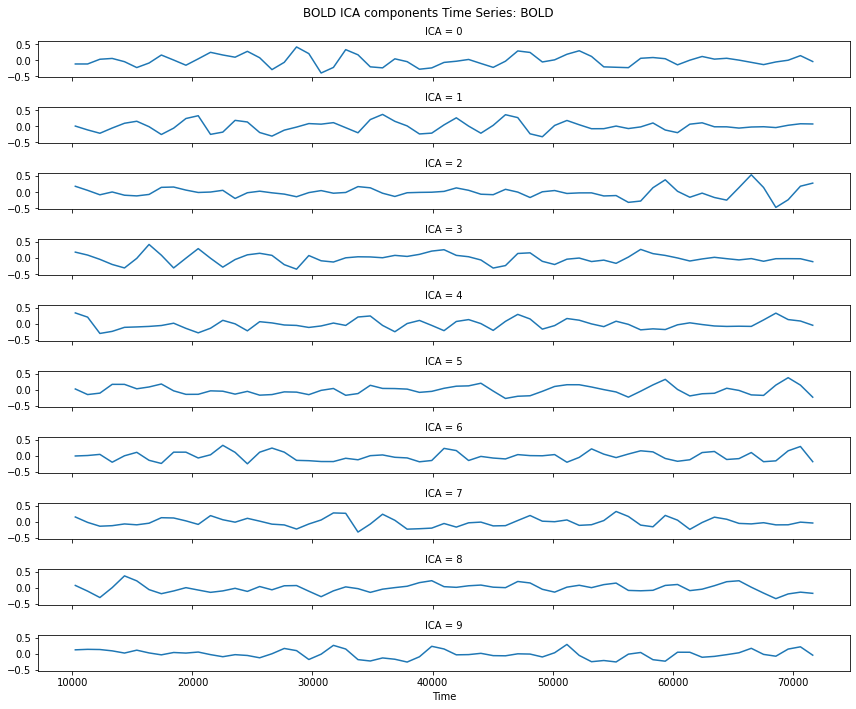

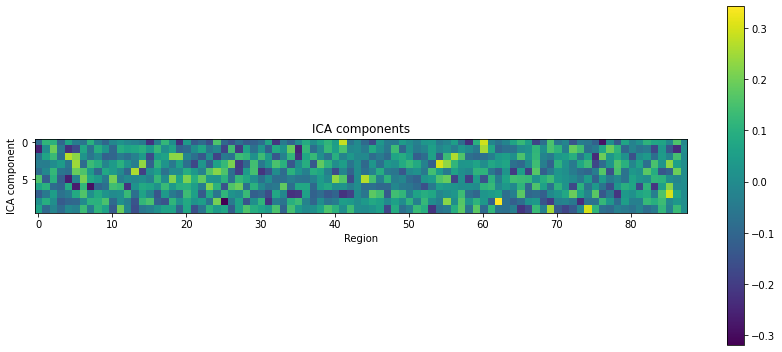

maximum correlation =  0.2531509428822525


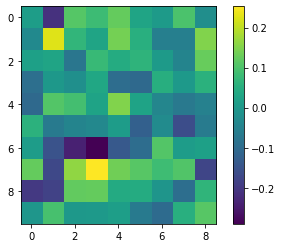

Indices of paired PCs with all 9 RS networks: ['X', 1, 'X', 'X', 'X', 'X', 'X', 3, 'X']
G = 8


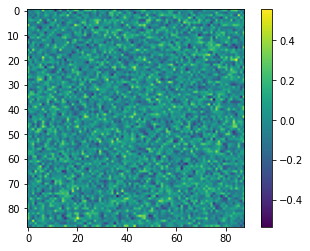

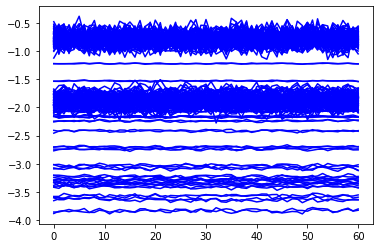

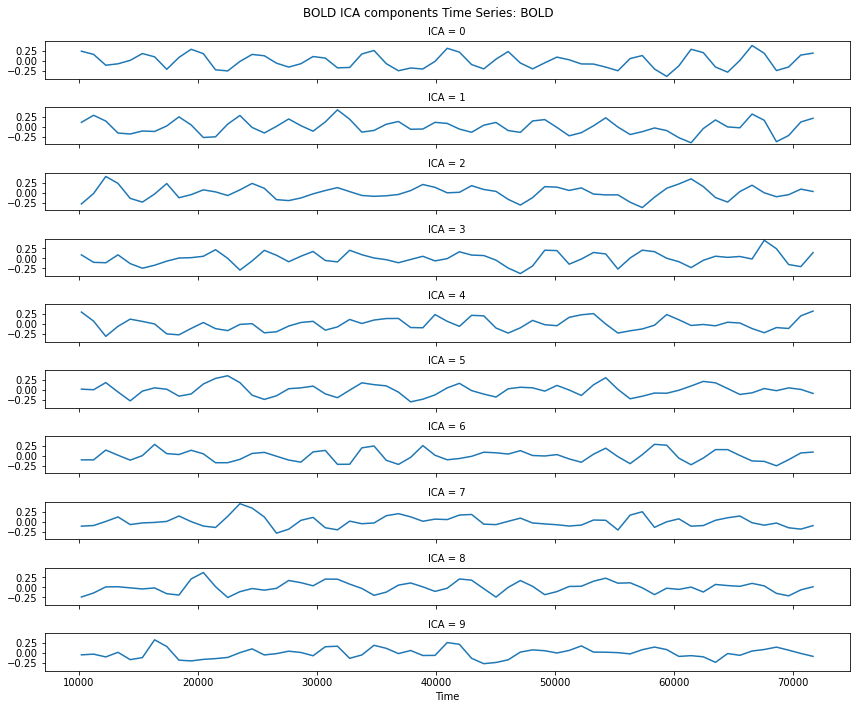

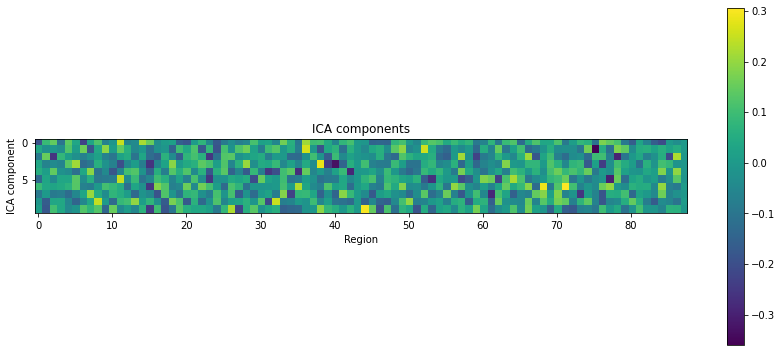

maximum correlation =  0.17812159417324633


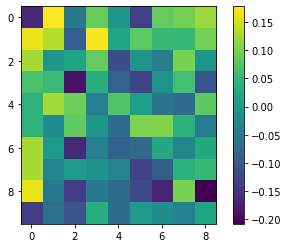

Indices of paired PCs with all 9 RS networks: [1, 3, 'X', 'X', 'X', 'X', 'X', 'X', 'X']
G = 9


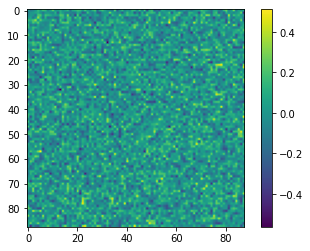

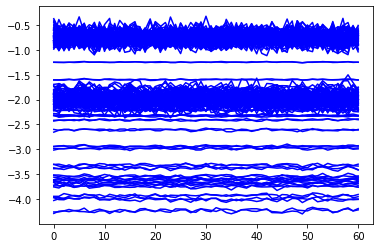

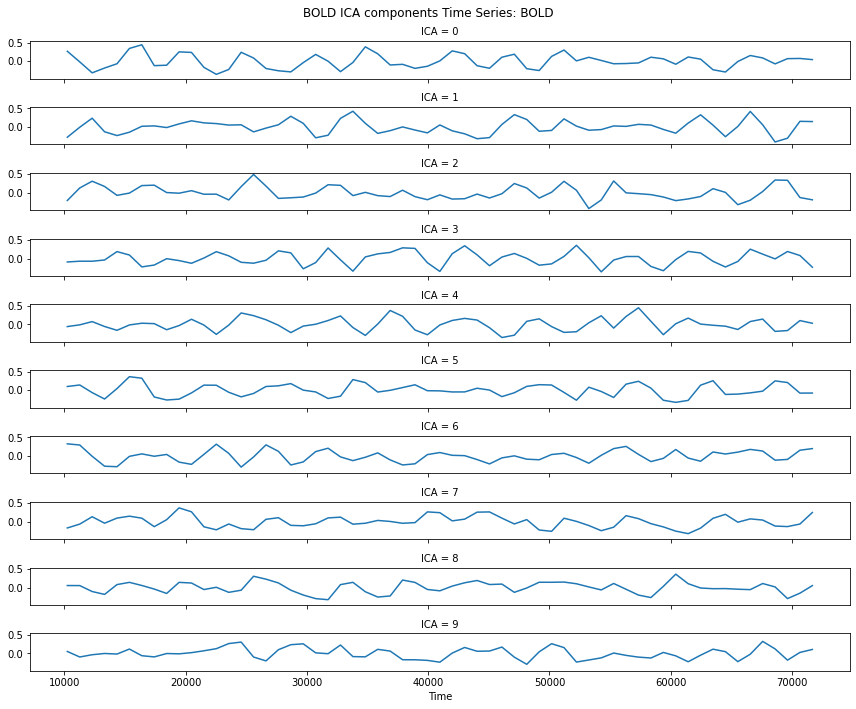

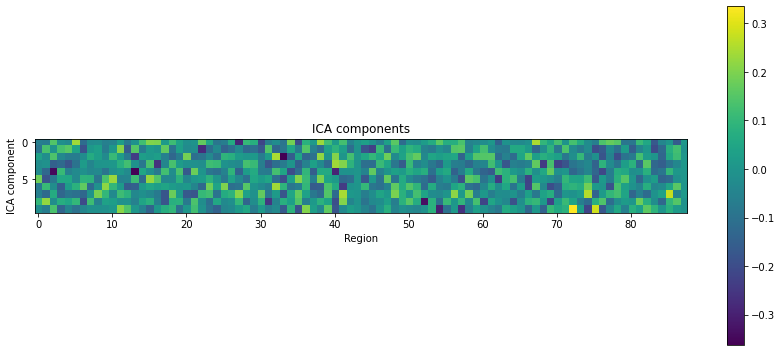

maximum correlation =  0.19909896022891949


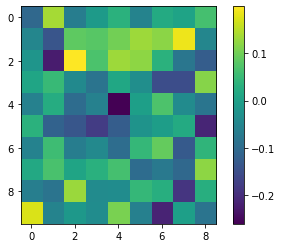

Indices of paired PCs with all 9 RS networks: ['X', 7, 2, 'X', 'X', 'X', 'X', 'X', 'X']
G = 10


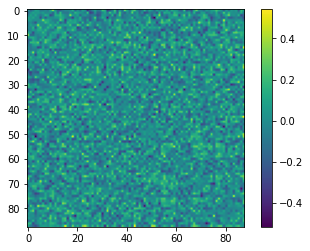

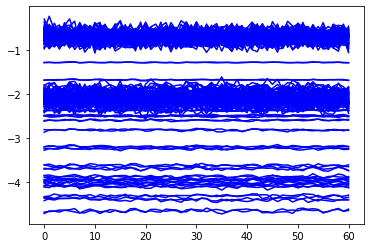

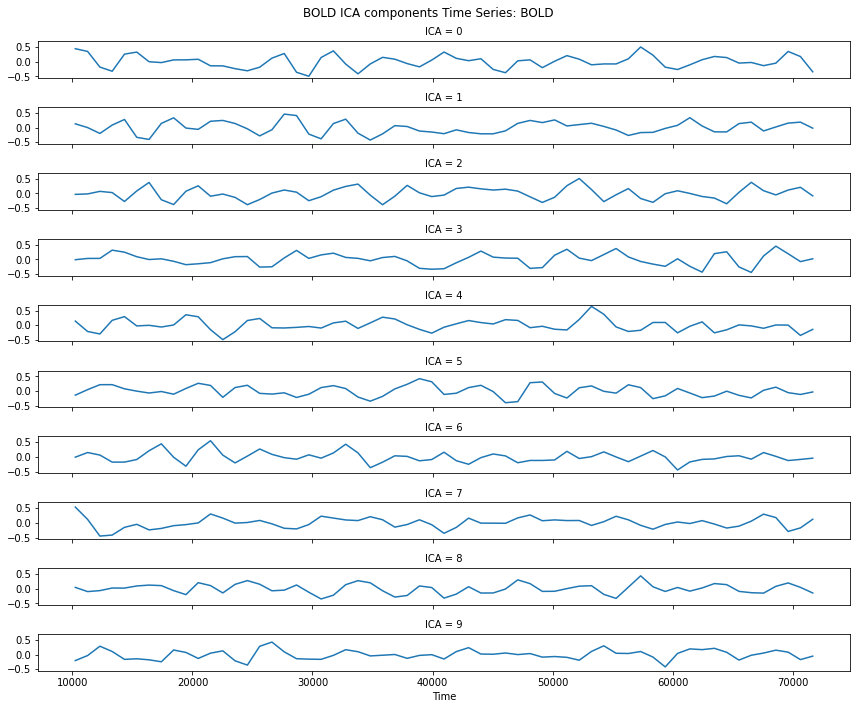

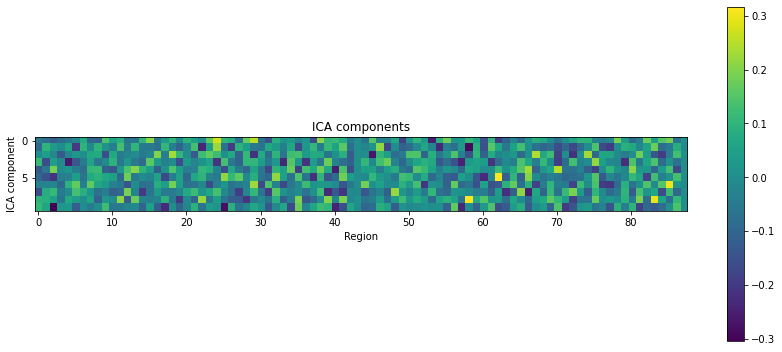

maximum correlation =  0.1872990046941892


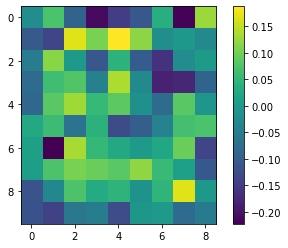

Indices of paired PCs with all 9 RS networks: ['X', 4, 'X', 'X', 'X', 'X', 'X', 'X', 'X']
G = 11


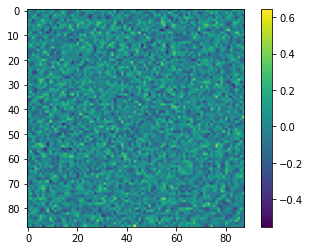

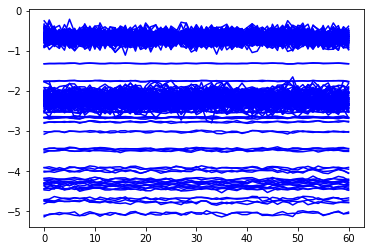

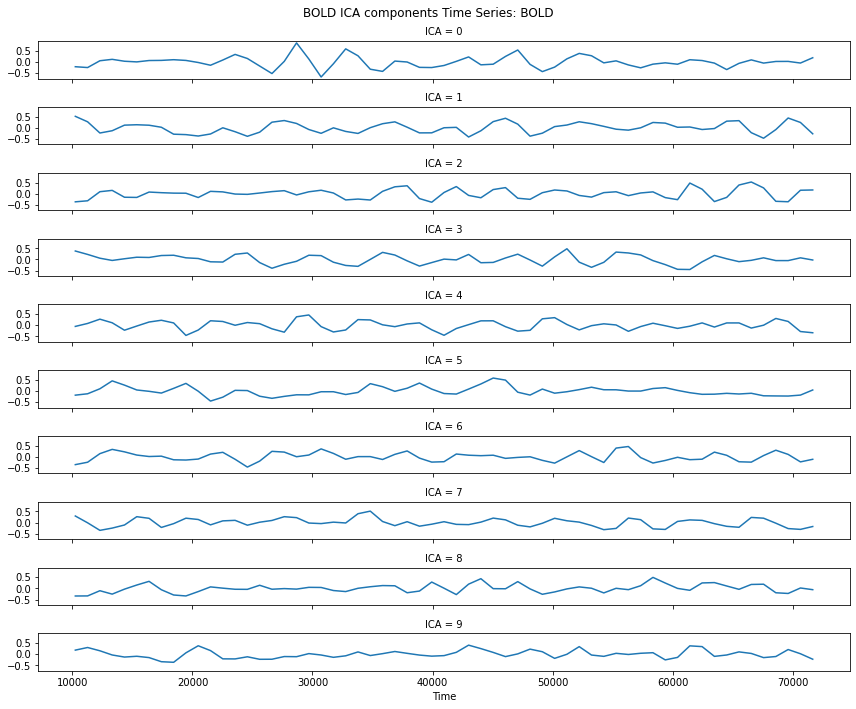

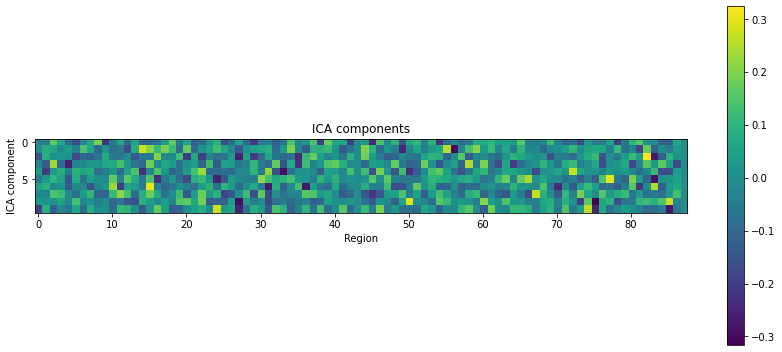

maximum correlation =  0.23856803154472064


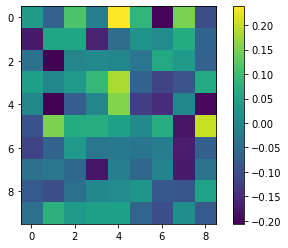

Indices of paired PCs with all 9 RS networks: [4, 'X', 'X', 4, 'X', 8, 'X', 'X', 'X']


In [3]:
topthree=[]
topthree_ICAs=[]
maxicorr=[]
each_ICA=[]
numbercaptured=[]
rows = 1
cols = 12
maxicorr = [[0 for _ in range(rows)] for _ in range(cols)]
mean_fc=[]
mean_fc_iso=[]
sum_fc_iso=[]

for jj in range(0,12):#12): #looping over all G values
    if jj==0:
        jj=0.1
        
    print('G =', jj)
    #################################################
    ## start by loading the simulated BOLD data
    #################################################
    path = glob.glob('/home/docker/packages/tvb-multiscale/examples/data/cerebellum/cwcBOLD/G' + str(jj) + "/*" + '/res')
    bold_G01 = path[0] + "/bold_ts.pkl"
    bold = load_pickled_dict(bold_G01)
    bold_times=bold['time']
    bold_ts=bold['time_series']
    bold_ts=np.squeeze(bold_ts[9:,0,:]).T #get rid of the trasient and transpose
    ffc=np.corrcoef(bold_ts)
    #################################################
    #plotting BOLD time series and FC
    #################################################
    
    for j in range(0,214):
        ffc[j,j]=0
    mean_fc.append(np.mean(np.mean(ffc)))
    ffc=np.delete(ffc, dd,1)
    ffc=np.delete(ffc, dd,0)
    mean_fc_iso.append(np.mean(np.mean(ffc)))
    sum_fc_iso.append(np.sum(ffc))
    plt.figure()
    plt.imshow(ffc)
    plt.colorbar()
    plt.show()
    
    
    plt.figure()
    plt.plot(bold_ts.T, 'b', label='All connections')
    plt.show()
    
    #################################################
    #let us calculate the ICA's and their regional involvement
    #################################################
    #function is in utils
    #delete the activities of the specific thalami before calculating ICA compoenents
    #print(bold_ts.shape)
    #bold_ts=np.delete(bold_ts, specthal,0)
    bold_ts=np.delete(bold_ts, dd,0)
    #delete also subcortical regions
    #bold_ts=np.delete(bold_ts,43:,0)
    
    #bold_ica_comps, bold_ics_ts, bold_ica = utils.compute_plot_ica(bold_ts.T, bold_times[9:], variable="BOLD", n_components=10, plotter=plotter)
    
    bold_ica_comps, bold_ics_ts, bold_ica = utils.compute_plot_pca(bold_ts.T, bold_times[9:], variable="BOLD", n_components=10, plotter=plotter)

    #I transposed above for FC, so now I need to transpose back
    #bold_ica_comps, bold_ics_ts, bold_ica = utils.compute_plot_ica(bold_ts.data[:, 0, :, 0].squeeze(), bold_times[9:], variable="BOLD", n_components=10, plotter=None)

    #we would like to calculate the correlation between the two vectors
    corr=[]
    rows = 9
    cols = 10
    corr = [[0 for _ in range(rows)] for _ in range(cols)]
    
    mean_corr=np.zeros(10)
    max_corr=np.zeros(10)
    l=0
    i=[]
    j=[]
    for i in bold_ica_comps:
        k=0
        #option 1:
        #i=abs(i) #take the absolute values of the ICAs
        #i = np.delete(i, specthal) #delete the ICA weights of the specific thalamic nodes
        # option 2: set low involvement to 0 ICA involvement
        #thres=0.01 #np.mean(abs(bold_ica_comps)) #np.median(abs(bold_ica_comps))#0.02
        #i[abs(i) < thres] = 0 #this sets all ICA values below thres to zero
        #threshold has no effect
        #option 3:
        #let us also make a 0 1 vector of ICAs
        #i[i >= thres] = 1 #this sets all ICA values above thres to 1
        for j in rs_net:
            #leave out the calculation of correlation for the specific thalamus regions 
            #j = np.delete(j, specthal)
            corr[l][k]=np.corrcoef(i,j)[0,1]
            k+=1
        #mean_corr[l]=np.mean(corr[:][l])
        max_corr[l]=np.max(corr[l][:]) #this gives the maximum correlation of this ICA with all RS nets
        l+=1
   
    
    #ind = np.argsort(corr)
    #print(ind)
    sorted_max=np.sort(max_corr) #minimum is first now
    sor_max=np.mean(sorted_max[-2:])#(len(sorted_max)-1))) #average over top 3 correlations only
    maxmax = np.max(max_corr)
    print('maximum correlation = ', maxmax)
    
    plt.figure()
    plt.imshow(corr)#, extent=[0, 1, 0, 1])
    plt.colorbar()
    plt.show()
    
    if jj==0.1:
        jj=0
    maxicorr[jj]=maxmax
    topthree.append(sor_max)
    #corr_value_G= np.mean(mean_corr)
    #corr_value_G
    #for each ICA we would like to know which RS comes closest and assign it, 9 RS nets and 10 ICAs
    #better: for each RS net, do we have a winner in ICAs?
    max_overICAs=[]
    max_overICAs_idx=[]
    kk=1
    for j in range(0,9):
        xx=np.max(corr[:][j]) #this gives the maximum correlation of this RS net with all ICAs
                #go over columns and find for each column = RS net its maximum
        #only check whether correlations are above 0.2
        if xx>=0.17:#0.2:
            max_overICAs.append(xx)
            yy=np.argmax(corr[:][j])  
            max_overICAs_idx.append(yy)  
        else:
            #max_overICAs.append(0) #write zero correlation when there is no corr higher than 0.2
            max_overICAs.append(xx)
            #yy=np.argmax(corr[:][j])  
            max_overICAs_idx.append('X')
            #yy=np.argmax(corr[:][j])  
#         yy=np.argmax(corr[:][j])  
#         max_overICAs_idx.append(yy)  
        #max_overICAs.append(xx)
    
    print('Indices of paired PCs with all 9 RS networks:', max_overICAs_idx) 
    #if this index is already taken, then take the second best option of the ICAs
    #unique, counts = np.unique(max_overICAs_idx, return_counts=True)
    #counts=counts[np.where(unique!='X')]
    #if counts > 0: #then we already used this ICA for another RS
        #compare both of the winning correlations
        #old = np.where(max_overICAs_idx==yy)
#         if xx > max_overICAs(old) #this is the current one
#             #then the current one is higher
#             max_overICAs_idx.append(yy)
#             #and we need to look for another one in the old one
#             sorted_corr=np.sort(corr[:][old]) #minimum is first now
#             xx=sorted_corr[-1]
#             #corr_temp=np.delete(corr, old,0)
#             #zz=np.max(corr_temp[:][j])
#         else #then the current one is lower
#             #then look for another one here
#             sorted_corr=np.sort(corr[:][j]) #minimum is first now
#             xx=sorted_corr[-1]
#             #max_overICAs_idx.append(yy)
    #else #then the current one is lower
    #    max_overICAs_idx.append(yy)
    python_indices  = [index for (index, item) in enumerate(max_overICAs_idx) if item != "X"]
    numbercaptured.append(len(python_indices))
    each_ICA.append(np.mean(max_overICAs)) #we take the average over these maxima
    sorted_maxx=np.sort(max_overICAs) #minimum is first now
    sor_maxx=np.mean(sorted_maxx[-2:])#(len(sorted_max)-1))) #average over top 3 correlations only
    topthree_ICAs.append(sor_maxx)
    #if yy in max_overICAs_idx: #if we already have this index chosen before
        #then compare with the previous correlation
    #    if xx < max_overICAs[max_overICAs_idx==yy] #when the previous correlation with another RS was higher
            #then choose another RS
    # next step: which G value is the best fit i.e. has the highest correlation with RS nets?
    #for that, calculate the corr value for each of the ICs with each of the RS nets, then average such that we have 
    # one corr value for each IC

In [4]:
#bold_ica_comps, bold_ics_ts, bold_ica = utils.compute_plot_pca(bold_ts.T, bold_times[9:], variable="BOLD", n_components=10, plotter=plotter)

In [5]:
max_overICAs #for each G we have this, maximum correlation of each of the 9 RS nets with all ICAs

[0.23856803154472064,
 0.0686918821507563,
 0.06227261493932565,
 0.18199659075176916,
 0.15566455105106164,
 0.19958028698763755,
 0.03345545634375945,
 -0.008092150883166106,
 0.04985406635620926]

In [6]:
max_overICAs_idx
#we have some ICAs that fit best with multiple RS nets, assign them only once to their highest RS contribution

[4, 'X', 'X', 4, 'X', 8, 'X', 'X', 'X']

In [7]:
numbercaptured

[2, 4, 4, 2, 2, 5, 5, 2, 2, 2, 1, 3]

In [8]:
python_indices  = [index for (index, item) in enumerate(max_overICAs_idx) if item != "X"]
print(python_indices)

[0, 3, 5]


Text(0, 0.5, 'number of captured RS nets with PCs (corr > 0.17)')

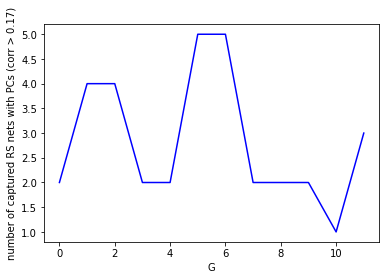

In [9]:
plt.plot(numbercaptured, 'b')
plt.xlabel('G')
plt.ylabel('number of captured RS nets with PCs (corr > 0.17)')

In [10]:
each_ICA

[0.14814645742235982,
 0.1561747351648772,
 0.15527460706758028,
 0.14282464573774323,
 0.13384619402877446,
 0.13485124182525063,
 0.20777493997637897,
 0.13654624248874447,
 0.1325925521523754,
 0.12057894882416191,
 0.13176107861577074,
 0.10911014769356374]

Text(0, 0.5, 'mean over the chosen max corr for each RS net a matching PC')

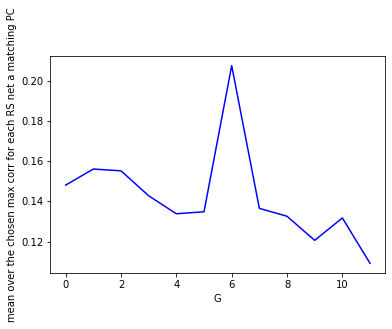

In [11]:
plt.plot(each_ICA, 'b')
plt.xlabel('G')
plt.ylabel('mean over the chosen max corr for each RS net a matching PC')

In [12]:
maxicorr

[0.3431020797919995,
 0.23144068631618908,
 0.3621267620266214,
 0.19014999399599591,
 0.3681749559768749,
 0.20926097282332212,
 0.3182368738370201,
 0.2531509428822525,
 0.17812159417324633,
 0.19909896022891949,
 0.1872990046941892,
 0.23856803154472064]

Text(0, 0.5, 'mean over the max corr of each ICA with an RS net')

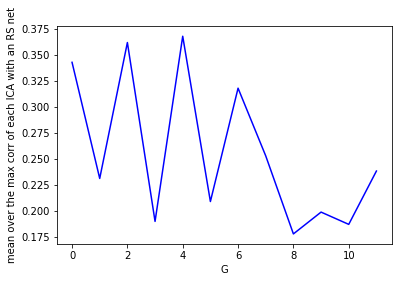

In [13]:
plt.plot(maxicorr, 'b')
plt.xlabel('G')
plt.ylabel('mean over the max corr of each ICA with an RS net')

In [14]:
#topthree

Text(0, 0.5, 'mean over the chosen top three ICA corr with each RS net')

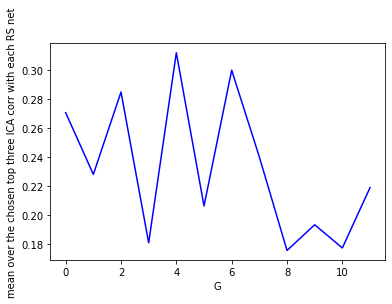

In [15]:
#plt.plot(topthree, 'b', label='All connections')
plt.plot(topthree_ICAs, 'b')
plt.xlabel('G')
plt.ylabel('mean over the chosen top three ICA corr with each RS net')

In [16]:
np.mean(abs(bold_ica_comps))

0.08383105096772096

In [17]:
np.median(abs(bold_ica_comps))

0.07060816296962558

In [18]:
np.median(bold_ica_comps)

0.0022254208898182587

In [19]:
np.max(bold_ica_comps)

0.3233085667824217

In [20]:
np.min(bold_ica_comps)

-0.31573355476769555

(array([ 14.,  24.,  66., 141., 208., 197., 131.,  74.,  15.,  10.]),
 array([-0.31573355, -0.25182934, -0.18792513, -0.12402092, -0.06011671,
         0.00378751,  0.06769172,  0.13159593,  0.19550014,  0.25940435,
         0.32330857]),
 <BarContainer object of 10 artists>)

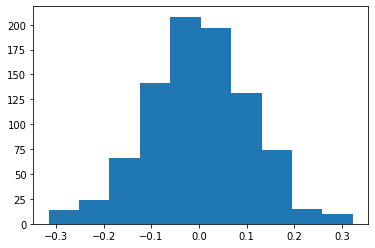

In [21]:
plt.hist(bold_ica_comps.flatten())
#np.histogram(bold_ica_comps)

In [22]:
bold['region_labels'][213]

'Left Interposed nucleus'

In [23]:
specthal

[43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 190,
 191,
 192]

In [24]:
subc

[86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 95,
 97,
 98,
 99,
 100,
 103,
 105,
 193,
 194,
 195,
 196,
 197,
 198,
 199,
 200,
 202,
 204,
 205,
 206,
 207,
 210,
 212]

In [25]:
ind

NameError: name 'ind' is not defined

In [ ]:
p=range(0,fc.shape[0])

In [ ]:
p

In [ ]:
mean_fc

In [ ]:
plt.plot(mean_fc, 'b')
plt.xlabel('G')
plt.ylabel('mean FC')

In [ ]:
plt.plot(mean_fc_iso, 'b')
plt.xlabel('G')
plt.ylabel('mean FC over isocortical regions')

In [ ]:
plt.plot(sum_fc_iso, 'b')
plt.xlabel('G')
plt.ylabel('total summed FC over isocortical regions')